The USGS monitoring station 02296750 at State Road 70 in Arcadia, Florida is crucial for understanding the Peace River's influence on the Charlotte Harbor estuarine system and red tides in the Gulf of Mexico. It provides long-term discharge and water level data, essential for assessing freshwater inflow, nutrient loading, and salinity—key factors driving harmful algal blooms like Karenia brevis. Its location near the river's mouth makes it valuable for studying freshwater-coastal interactions. While other stations, such as 02295637 at Zolfo Springs and 02294898 at Fort Meade, also monitor discharge and water levels, Arcadia’s strategic position and historical data since 1912 make it particularly valuable for predicting and managing red tide events.

In [ ]:
path='data/NHD_H_03100101_HU8_Shape'

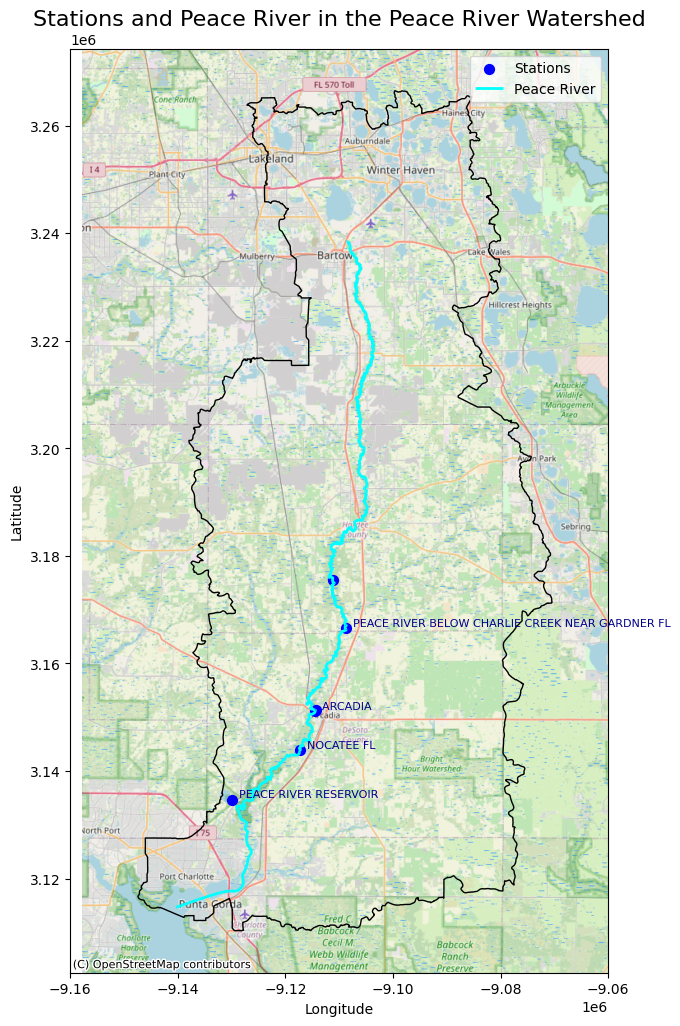

In [32]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely import wkb

# Load the CSV file (update path if needed)
file_path = 'data/DataDownload_4344079_row.csv'
data = pd.read_csv(file_path)

# Filter the data for Elevation and Flow parameters
filtered_data = data[data['Parameter'].isin(['Level_FT_NAVD88', 'Flow_CFS'])]
filtered_data = filtered_data.dropna(subset=['Latitude_DD', 'Longitude_DD'])

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    filtered_data, 
    geometry=gpd.points_from_xy(filtered_data['Longitude_DD'], filtered_data['Latitude_DD']),
    crs='EPSG:4326'
)

# ✅ Remove duplicates based on station location and name
unique_stations = gdf[['StationName', 'geometry']].drop_duplicates()

# ✅ Filter for stations close to the Gulf of Mexico
gulf_stations = unique_stations[
    (unique_stations.geometry.y <= 27.5) & 
    (unique_stations.geometry.y >= 26.5) & 
    (unique_stations.geometry.x >= -82.5) & 
    (unique_stations.geometry.x <= -81.5)
]

# Load the Peace River Watershed shapefile
watershed = gpd.read_file(f'{path}/Shape/WBDHU8.shp')

# Load the NHD flowline data
flowlines = gpd.read_file(f'{path}/Shape/NHDFlowline.shp')

# ✅ Convert to 2D geometry (strip Z values)
flowlines['geometry'] = flowlines['geometry'].apply(
    lambda geom: wkb.loads(wkb.dumps(geom, output_dimension=2))
)

# ✅ Filter the flowlines to select only Peace River
peace_river = flowlines[flowlines['gnis_name'].str.strip().str.lower() == 'peace river']

# ✅ Define available basemaps
basemaps = {
    'OpenStreetMap': ctx.providers.OpenStreetMap.Mapnik,
    'CartoDB Positron': ctx.providers.CartoDB.Positron,
    'CartoDB DarkMatter': ctx.providers.CartoDB.DarkMatter,
    'CartoDB Voyager': ctx.providers.CartoDB.Voyager,
    'Esri World Imagery': ctx.providers.Esri.WorldImagery,
    'Esri World Topo Map': ctx.providers.Esri.WorldTopoMap
}

# ✅ Select basemap
choice = 1  # 1 = OpenStreetMap
selected_basemap = list(basemaps.values())[choice - 1]

# ✅ Plotting
fig, ax = plt.subplots(figsize=(14, 12))

# Plot watershed boundary
watershed.to_crs(epsg=3857).plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1)

# Plot the stations near the Gulf of Mexico
gulf_stations.to_crs(epsg=3857).plot(ax=ax, markersize=50, color='blue', label='Stations')

# ✅ Add station names:
# - Remove 'Peace River' from labels
# - Plot every second station except the last one

for i, row in enumerate(gulf_stations.to_crs(epsg=3857).iterrows()):
    label = row[1]['StationName'].replace('PEACE RIVER AT ', '').replace('Peace River at ', '')
    
    if i % 2 == 0 or i == len(gulf_stations) - 1:  # Always show the last station
        ax.text(row[1].geometry.x, row[1].geometry.y, label, 
                fontsize=8, ha='left', va='bottom', color='darkblue')

# Plot the Peace River
peace_river.to_crs(epsg=3857).plot(ax=ax, color='cyan', label='Peace River', linewidth=2)

# ✅ Add selected basemap (lower resolution for faster rendering)
ctx.add_basemap(ax, source=selected_basemap, zoom=10) 

# ✅ Fix x-axis label crowding (reduce number of ticks)
ax.set_xticks(ax.get_xticks()[::2])  # Show every second tick to reduce clutter

# Customize plot
plt.title('Stations and Peace River in the Peace River Watershed', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()

# ✅ Save figure
plt.savefig('map_cleaned.png', dpi=300)

plt.show()


The discharge data from USGS station 02296750 represents the daily streamflow measurements for the Peace River at Arcadia, Florida in cubic feet per second (cfs). The data spans from October 1, 1985, to the present, capturing seasonal variations, storm events, and long-term hydrological trends. The station is part of the USGS National Water Information System (NWIS), which follows standardized methods for data collection and processing. However, the data may contain uncertainties due to factors such as instrument calibration errors, changes in channel geometry, flow estimation methods, and environmental factors like debris or vegetation influencing water flow. The data is marked with an approval code ('A'), indicating that it has been quality-checked and meets USGS data accuracy standards, but users should still account for potential measurement errors and missing data when analyzing trends.









In [35]:
import dataretrieval.nwis as nwis

# Site number and parameter code for discharge (00060)
site = '02296750'
parameter = '00060'
start_date = '1985-01-01'
end_date = '2025-01-01'

# Retrieve data
df = nwis.get_record(sites=site, parameterCd=parameter, start=start_date, end=end_date)

# Display data
print(df.head())

# Save to CSV
df.to_csv('peace_river_discharge.csv', index=True)


                            site_no  00060 00060_cd
datetime                                           
1987-10-20 05:00:00+00:00  02296750  987.0  A, [92]
1987-10-20 06:00:00+00:00  02296750  983.0  A, [92]
1987-10-20 07:00:00+00:00  02296750  979.0  A, [92]
1987-10-20 08:00:00+00:00  02296750  976.0  A, [92]
1987-10-20 09:00:00+00:00  02296750  972.0  A, [92]


In [40]:
import dataretrieval.nwis as nwis
import matplotlib.pyplot as plt

# Define station ID and parameter for discharge
site = '02297100'  # Nocatee, FL station ID
parameter = '00060'  # Discharge in cfs
start_date = '1985-01-01'
end_date = '2025-01-01'

# Retrieve data
nocatee_data = nwis.get_record(sites=site, parameterCd=parameter, start=start_date, end=end_date)

# Save the data to CSV (optional)
nocatee_data.to_csv('peace_river_discharge_nocatee.csv')


When analyzing discharge data from the Peace River at both Arcadia and Nocatee stations, it's evident that the Arcadia station (USGS 02296750) records higher flow rates compared to the Nocatee station (USGS 02297100). This discrepancy arises because the Arcadia station monitors the main stem of the Peace River, capturing cumulative flow from a larger upstream drainage area, whereas the Nocatee station measures discharge from Joshua Creek, a smaller tributary within the Peace River Basin.

For studying red tides in the Gulf of Mexico, discharge data from the Arcadia station is more pertinent. The Peace River is a significant contributor of freshwater and associated nutrients to Charlotte Harbor, which subsequently influences coastal waters where red tides occur. Monitoring at Arcadia provides a comprehensive understanding of the total freshwater inflow and nutrient loads entering the estuarine and coastal systems, thereby offering valuable insights into factors that may exacerbate red tide events. 

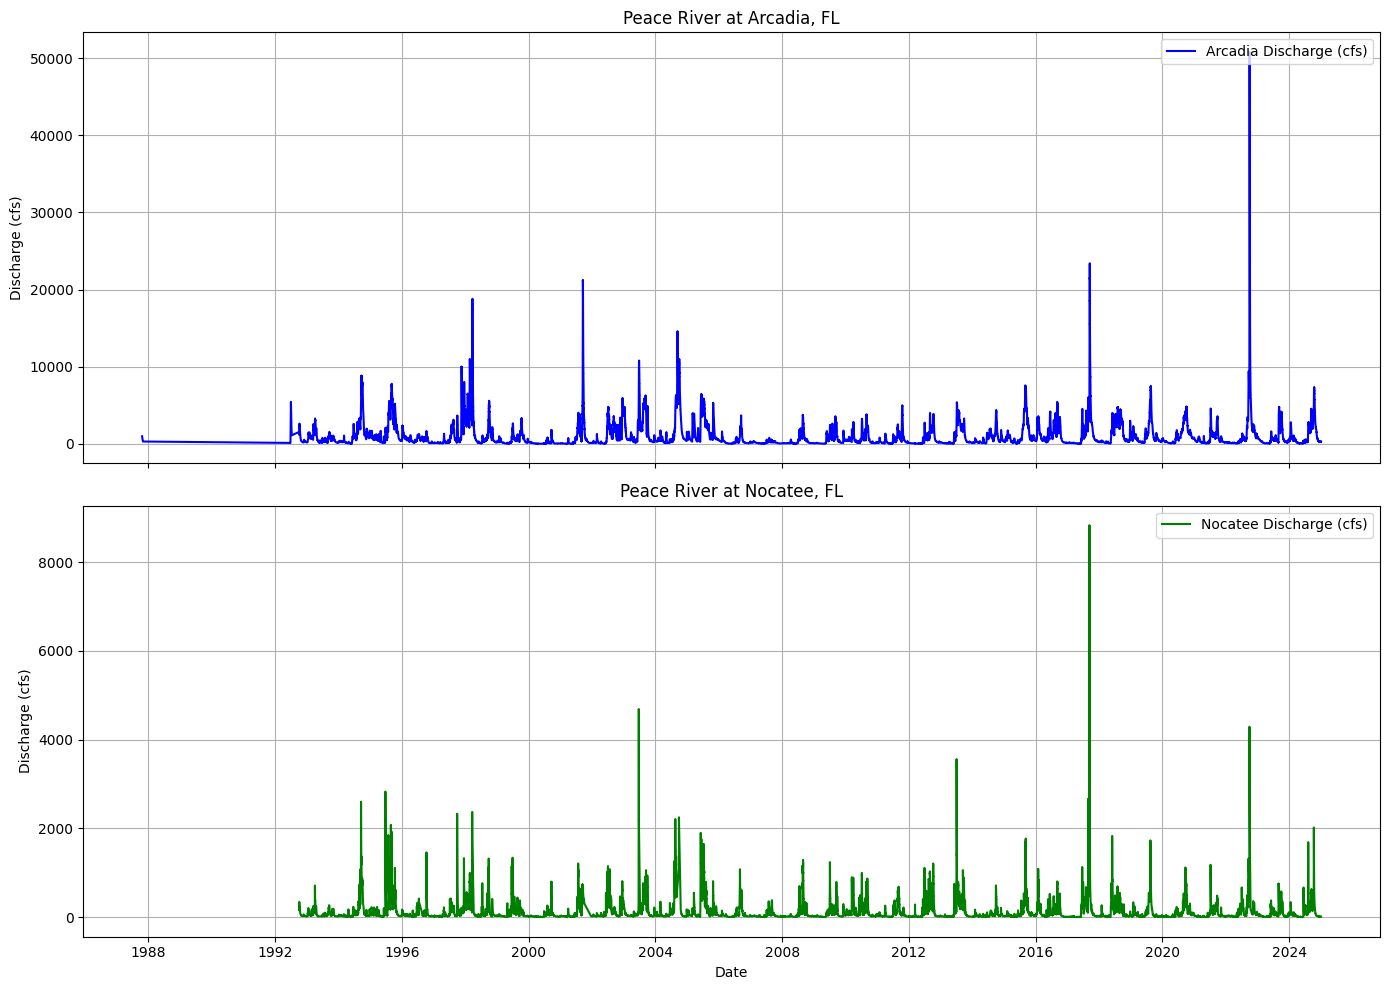

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the discharge data for both Arcadia and Nocatee from CSV files
file_arcadia = 'peace_river_discharge_arcadia.csv'
file_nocatee = 'peace_river_discharge_nocatee.csv'

# Read data files
discharge_arcadia = pd.read_csv(file_arcadia)
discharge_nocatee = pd.read_csv(file_nocatee)

# Convert 'datetime' columns to datetime format
discharge_arcadia['datetime'] = pd.to_datetime(discharge_arcadia['datetime'])
discharge_nocatee['datetime'] = pd.to_datetime(discharge_nocatee['datetime'])

# Create subplots for Arcadia and Nocatee
fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot for Arcadia
axs[0].plot(discharge_arcadia['datetime'], discharge_arcadia['00060'], label='Arcadia Discharge (cfs)', color='blue')
axs[0].set_ylabel('Discharge (cfs)')
axs[0].set_title('Peace River at Arcadia, FL')
axs[0].legend(loc='upper right')
axs[0].grid(True)

# Plot for Nocatee
axs[1].plot(discharge_nocatee['datetime'], discharge_nocatee['00060'], label='Nocatee Discharge (cfs)', color='green')
axs[1].set_ylabel('Discharge (cfs)')
axs[1].set_title('Peace River at Nocatee, FL')
axs[1].legend(loc='upper right')
axs[1].grid(True)

# Set common x-label
plt.xlabel('Date')

# Adjust spacing between subplots
plt.tight_layout()

plt.savefig('discharge.png')
# Display the plot
plt.show()



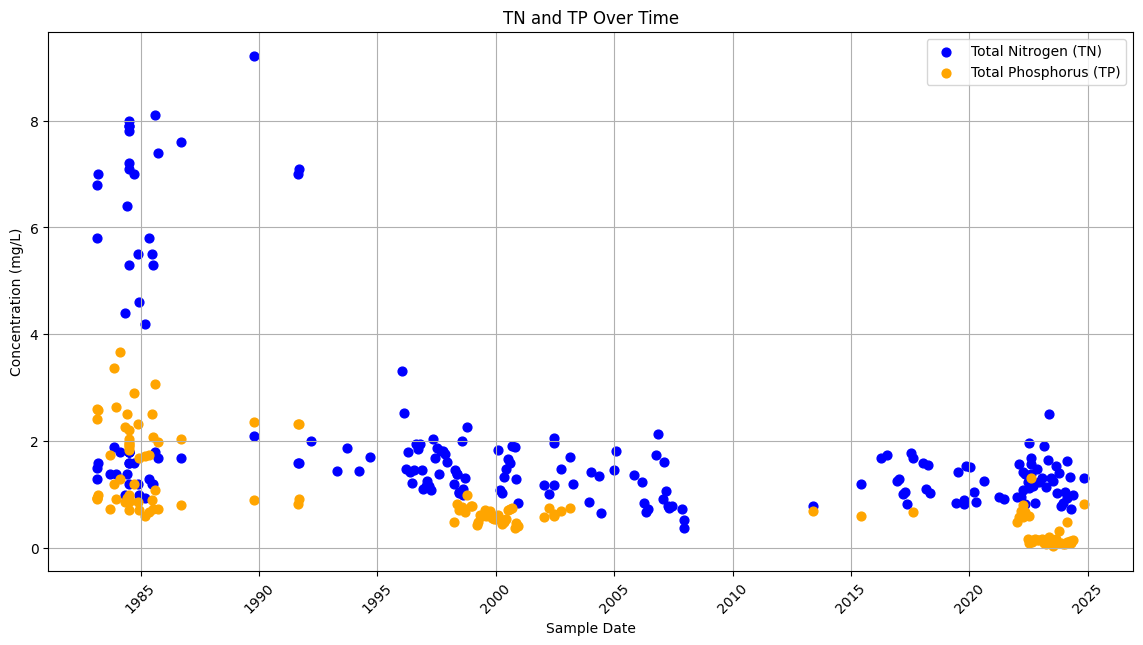

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the file (adjust path if needed)
file_path = 'TN_TP.csv'  # Adjust path if needed
df = pd.read_csv(file_path)

# Convert SampleDate to datetime and drop invalid dates
df['SampleDate'] = pd.to_datetime(df['SampleDate'], errors='coerce')
df = df.dropna(subset=['SampleDate'])

# Filter TN and TP data
tn_data = df[df['Parameter'] == 'TN_mgl']
tp_data = df[df['Parameter'] == 'TP_mgl']

# Sort by SampleDate
tn_data = tn_data.sort_values(by='SampleDate')
tp_data = tp_data.sort_values(by='SampleDate')

# Plot TN and TP as points
plt.figure(figsize=(14, 7))
plt.scatter(tn_data['SampleDate'], tn_data['Result_Value'], label='Total Nitrogen (TN)', color='blue', s=40)
plt.scatter(tp_data['SampleDate'], tp_data['Result_Value'], label='Total Phosphorus (TP)', color='orange', s=40)

# Add labels and title
plt.xlabel('Sample Date')
plt.ylabel('Concentration (mg/L)')
plt.title('TN and TP Over Time')

# Add legend
plt.legend()

# Improve formatting
plt.xticks(rotation=45)
plt.grid(True)

# Show plot
plt.show()


C:\Users\aelshall\AppData\Local\Temp\ipykernel_14780\2269569750.py:100: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


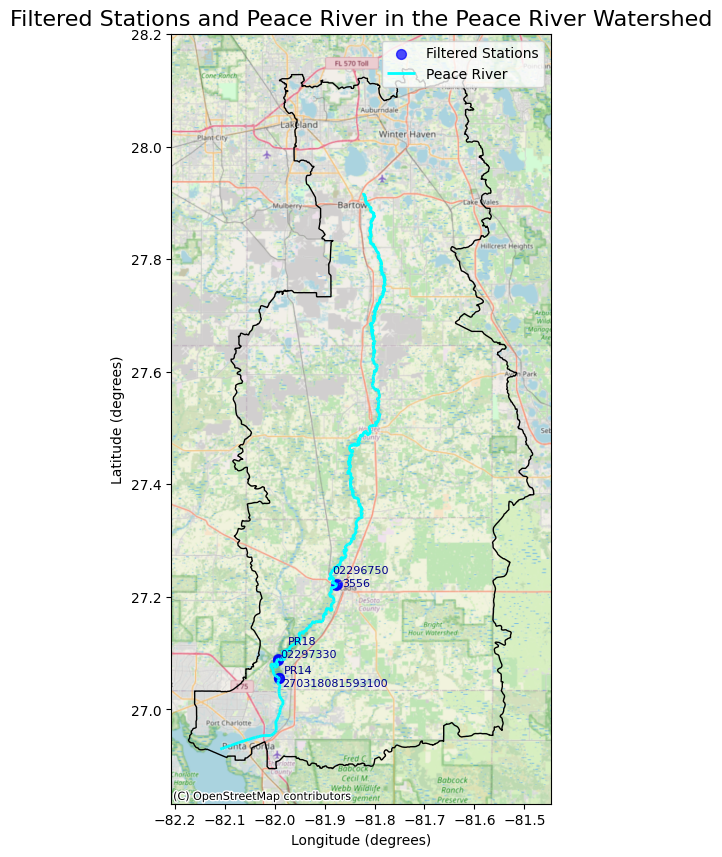

In [78]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point
from adjustText import adjust_text

# ✅ Load the data
file_path = 'TN_TP.csv'
data = pd.read_csv(file_path)

# ✅ Convert coordinates to float64 to maintain precision
data['Actual_Latitude'] = data['Actual_Latitude'].astype('float64')
data['Actual_Longitude'] = data['Actual_Longitude'].astype('float64')

# ✅ Drop rows with missing coordinates
data = data.dropna(subset=['Actual_Latitude', 'Actual_Longitude'])

# ✅ Filter out data before 1990
data['SampleDate'] = pd.to_datetime(data['SampleDate'])
data = data[data['SampleDate'].dt.year >= 1990]

# ✅ Create a summary table for each station
summary = data.groupby('StationID').agg(
    WBodyID=('WBodyID', 'first'),
    WaterBodyName=('WaterBodyName', 'first'),
    DataSource=('DataSource', 'first'),
    StationName=('StationName', 'first'),
    Actual_Latitude=('Actual_Latitude', 'first'),
    Actual_Longitude=('Actual_Longitude', 'first'),
    TN_Samples=('Parameter', lambda x: (x == 'TN_mgl').sum() + (x == 'TN_ugl').sum()),
    TP_Samples=('Parameter', lambda x: (x == 'TP_mgl').sum() + (x == 'TP_ugl').sum()),
    StartDate=('SampleDate', 'min'),
    EndDate=('SampleDate', 'max')
).reset_index()

# ✅ Filter stations that have 10 or more sample points for either TN or TP
stations_with_10_or_more_samples = summary[
    (summary['TN_Samples'] >= 30) | (summary['TP_Samples'] >= 30)
]

# ✅ Remove stations above latitude 27.4 to keep only Gulf-proximate stations
stations_with_10_or_more_samples = stations_with_10_or_more_samples[
    stations_with_10_or_more_samples['Actual_Latitude'] <= 27.4
]

# ✅ Convert to GeoDataFrame
filtered_gdf = gpd.GeoDataFrame(
    stations_with_10_or_more_samples,
    geometry=[Point(xy) for xy in zip(
        stations_with_10_or_more_samples['Actual_Longitude'],
        stations_with_10_or_more_samples['Actual_Latitude']
    )],
    crs='EPSG:4326'
)

# ✅ Load Peace River Watershed shapefile
path = 'data/NHD_H_03100101_HU8_Shape'
watershed = gpd.read_file(f'{path}/Shape/WBDHU8.shp').to_crs(epsg=4326)

# ✅ Load Peace River flowline data
flowlines = gpd.read_file(f'{path}/Shape/NHDFlowline.shp').to_crs(epsg=4326)

# ✅ Filter for Peace River flowline
peace_river = flowlines[flowlines['gnis_name'].str.strip().str.lower() == 'peace river']

# ✅ Plotting
fig, ax = plt.subplots(figsize=(12, 10))

# Plot watershed boundary
watershed.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1, label='Watershed Boundary')

# Plot filtered stations
filtered_gdf.plot(ax=ax, markersize=50, color='blue', label='Filtered Stations', alpha=0.7)

# Plot Peace River
peace_river.plot(ax=ax, color='cyan', label='Peace River', linewidth=2)

# ✅ Add station labels using adjustText to avoid overlap
texts = []
for x, y, label in zip(
    filtered_gdf.geometry.x, 
    filtered_gdf.geometry.y, 
    filtered_gdf['StationID']
):
    texts.append(ax.text(x, y, label, fontsize=8, ha='left', va='bottom', color='darkblue'))

# ✅ Automatically adjust text to prevent overlap
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# ✅ Add basemap without changing CRS
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs='EPSG:4326')

# ✅ Fix axis labels to show degrees (latitude and longitude)
ax.set_xlabel('Longitude (degrees)')
ax.set_ylabel('Latitude (degrees)')

# ✅ Customize plot
plt.title('Filtered Stations and Peace River in the Peace River Watershed', fontsize=16)
plt.legend()

# ✅ Save and show plot
plt.savefig('filtered_stations_map_fixed.png', dpi=300)
plt.show()


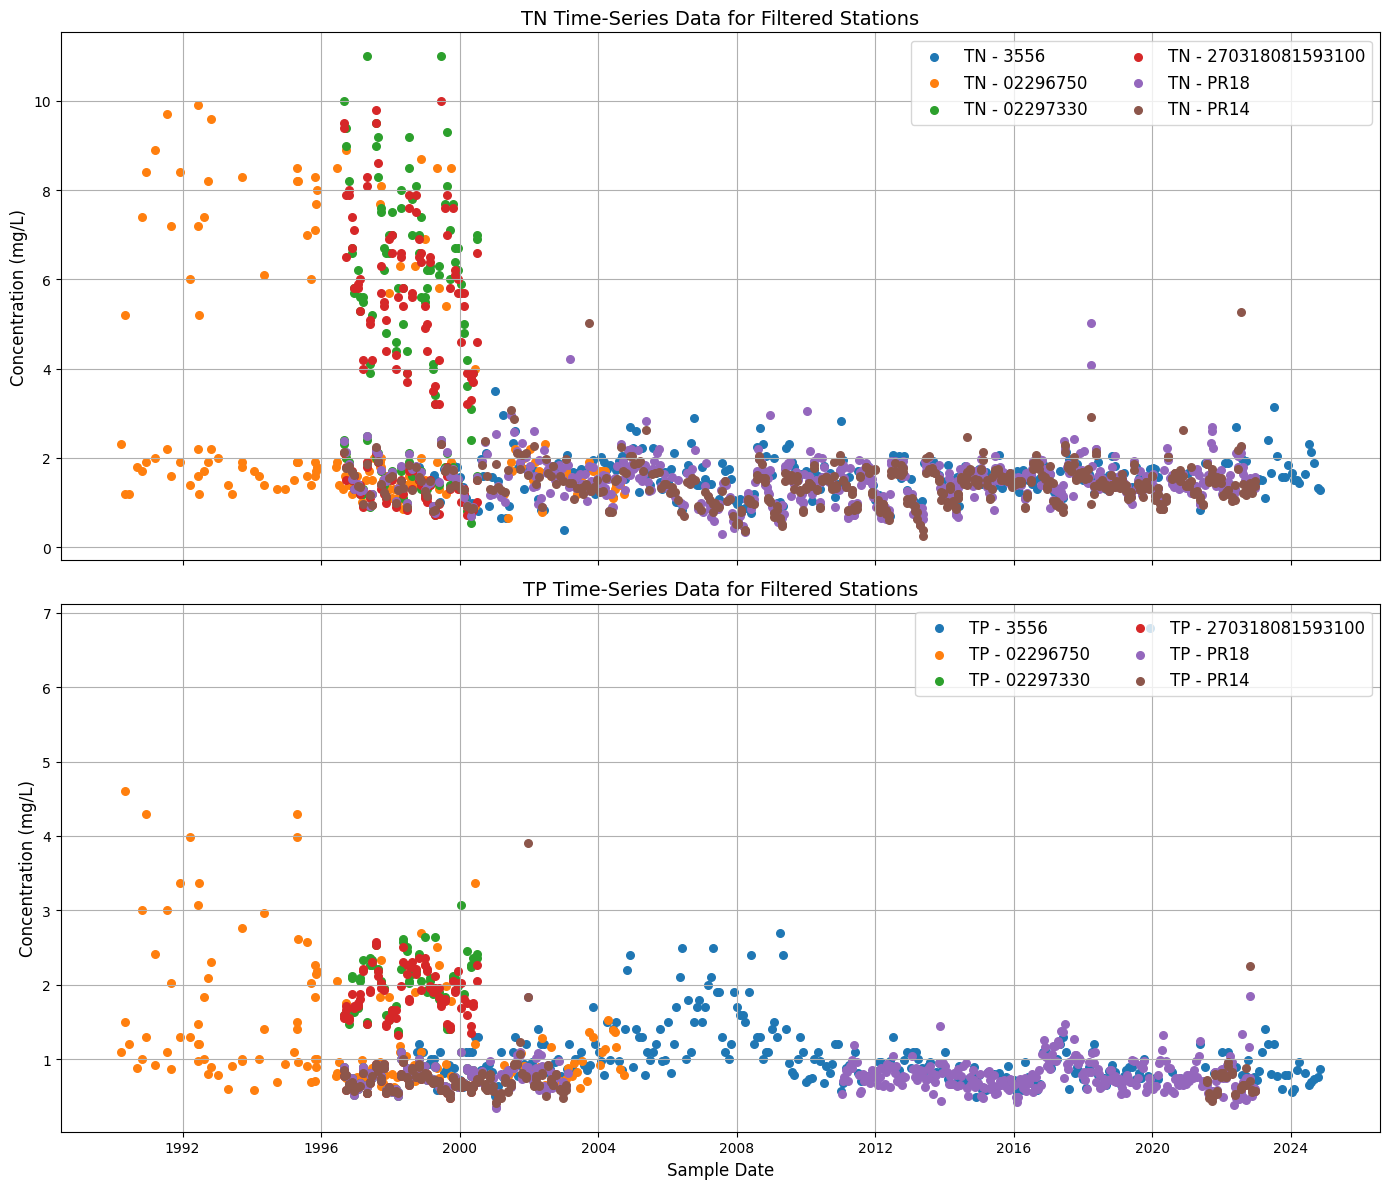

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

# ✅ Load the data
file_path = 'TN_TP.csv'
data = pd.read_csv(file_path)

# ✅ Convert coordinates to float64 to maintain precision
data['Actual_Latitude'] = data['Actual_Latitude'].astype('float64')
data['Actual_Longitude'] = data['Actual_Longitude'].astype('float64')

# ✅ Drop rows with missing coordinates
data = data.dropna(subset=['Actual_Latitude', 'Actual_Longitude'])

# ✅ Filter out data before 1990
data['SampleDate'] = pd.to_datetime(data['SampleDate'])
data = data[data['SampleDate'].dt.year >= 1990]

# ✅ Create a summary table for each station
summary = data.groupby('StationID').agg(
    WBodyID=('WBodyID', 'first'),
    WaterBodyName=('WaterBodyName', 'first'),
    DataSource=('DataSource', 'first'),
    StationName=('StationName', 'first'),
    Actual_Latitude=('Actual_Latitude', 'first'),
    Actual_Longitude=('Actual_Longitude', 'first'),
    TN_Samples=('Parameter', lambda x: (x == 'TN_mgl').sum() + (x == 'TN_ugl').sum()),
    TP_Samples=('Parameter', lambda x: (x == 'TP_mgl').sum() + (x == 'TP_ugl').sum()),
    StartDate=('SampleDate', 'min'),
    EndDate=('SampleDate', 'max')
).reset_index()

# ✅ Filter stations that have 30 or more sample points for either TN or TP
filtered_stations = summary[
    (summary['TN_Samples'] >= 30) | (summary['TP_Samples'] >= 30)
]

# ✅ Remove stations above latitude 27.4 (keep Gulf-proximate stations)
filtered_stations = filtered_stations[filtered_stations['Actual_Latitude'] <= 27.4]

# ✅ Keep only data from filtered stations
filtered_data = data[data['StationID'].isin(filtered_stations['StationID'])]

# ✅ Separate TN and TP data
tn_data = filtered_data[filtered_data['Parameter'].isin(['TN_mgl', 'TN_ugl'])]
tp_data = filtered_data[filtered_data['Parameter'].isin(['TP_mgl', 'TP_ugl'])]

# ✅ Convert concentration to consistent units (mg/L) if necessary
tn_data.loc[tn_data['Parameter'] == 'TN_ugl', 'Result_Value'] /= 1000
tp_data.loc[tp_data['Parameter'] == 'TP_ugl', 'Result_Value'] /= 1000

# ✅ Create subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12), sharex=True)

# ✅ Plot TN in the first subplot as dots
for station_id in tn_data['StationID'].unique():
    station_data = tn_data[tn_data['StationID'] == station_id]
    axes[0].scatter(station_data['SampleDate'], station_data['Result_Value'], label=f'TN - {station_data["StationID"].iloc[0]}', s=30)

# ✅ Customize TN plot
axes[0].set_title('TN Time-Series Data for Filtered Stations', fontsize=14)
axes[0].set_ylabel('Concentration (mg/L)', fontsize=12)
axes[0].legend(fontsize=12, loc='upper right', ncol=2)
axes[0].grid(True)

# ✅ Plot TP in the second subplot as dots
for station_id in tp_data['StationID'].unique():
    station_data = tp_data[tp_data['StationID'] == station_id]
    axes[1].scatter(station_data['SampleDate'], station_data['Result_Value'], label=f'TP - {station_data["StationID"].iloc[0]}', s=30)

# ✅ Customize TP plot
axes[1].set_title('TP Time-Series Data for Filtered Stations', fontsize=14)
axes[1].set_xlabel('Sample Date', fontsize=12)
axes[1].set_ylabel('Concentration (mg/L)', fontsize=12)
axes[1].legend(fontsize=12, loc='upper right', ncol=2)
axes[1].grid(True)

# ✅ Adjust spacing between subplots
plt.tight_layout()

# ✅ Save and show plot
plt.savefig('TN_TP_TimeSeries_Dots.png', dpi=300)
plt.show()


In [96]:
import requests
import pandas as pd
from io import StringIO
import datetime

def download_noaa_buoy_data(station_id, start_year, end_year):
    """Downloads historical NOAA buoy data."""

    all_data = []

    for year in range(start_year, end_year + 1):
        gz_url = f"https://www.ndbc.noaa.gov/view_text_file.php?filename={station_id}h{year}.txt.gz&dir=data/history/{station_id}/"
        txt_url = f"https://www.ndbc.noaa.gov/view_text_file.php?filename={station_id}h{year}.txt&dir=data/history/{station_id}/"  # Uncompressed URL
        try:
            response = requests.get(gz_url, stream=True)
            response.raise_for_status()

            try:
                import gzip
                with gzip.GzipFile(fileobj=response.raw, mode='rb') as f:
                    data = pd.read_csv(f, delim_whitespace=True, skiprows=[1])
            except gzip.BadGzipFile:
                print(f"Warning: Gzip error for {year}, trying without decompression.")
                data = pd.read_csv(StringIO(response.text), delim_whitespace=True, skiprows=[1])

        except requests.exceptions.HTTPError as e:
            if e.response.status_code == 404: # if the gz file is not found, try the txt file.
                try:
                    response = requests.get(txt_url)
                    response.raise_for_status()
                    data = pd.read_csv(StringIO(response.text), delim_whitespace=True, skiprows=[1])
                except requests.exceptions.HTTPError as e2:
                    print(f"Error downloading data for {year}: {e2}")
                    continue
            else:
                print(f"Error downloading data for {year}: {e}")
                continue
        except requests.exceptions.RequestException as e:
            print(f"Error downloading data for {year}: {e}")
            continue
        except pd.errors.ParserError as e:
            print(f"Error parsing data for {year}: {e}")
            continue
        except Exception as e:
            print(f"An unexpected error occurred for {year}: {e}")
            continue

        all_data.append(data)

    if all_data:
        combined_data = pd.concat(all_data, ignore_index=True)

        try:
            combined_data['datetime'] = pd.to_datetime(combined_data[['#YY', 'MM', 'DD', 'hh', 'mm']])
            combined_data = combined_data.drop(columns=['#YY', 'MM', 'DD', 'hh', 'mm'])
            combined_data = combined_data.set_index('datetime')
        except KeyError as e:
            print(f"Error during date/time conversion: {e}")
            return None

        return combined_data
    else:
        return None

station_id = "42003"
start_year = 1990
end_year = datetime.datetime.now().year

data = download_noaa_buoy_data(station_id, start_year, end_year)

if data is not None:
    print(f"Data downloaded successfully for station {station_id} from {start_year} to {end_year}.")
    print(data.head())
    #data.to_csv("42003_1990_present.csv")
else:
    print(f"Failed to download data for station {station_id}.")

Error downloading data for 1990: 404 Client Error: Not Found for url: https://www.ndbc.noaa.gov/view_text_file.php?filename=42003h1990.txt&dir=data/history/42003/
Error downloading data for 1991: 404 Client Error: Not Found for url: https://www.ndbc.noaa.gov/view_text_file.php?filename=42003h1991.txt&dir=data/history/42003/
Error downloading data for 1992: 404 Client Error: Not Found for url: https://www.ndbc.noaa.gov/view_text_file.php?filename=42003h1992.txt&dir=data/history/42003/
Error downloading data for 1993: 404 Client Error: Not Found for url: https://www.ndbc.noaa.gov/view_text_file.php?filename=42003h1993.txt&dir=data/history/42003/
Error downloading data for 1994: 404 Client Error: Not Found for url: https://www.ndbc.noaa.gov/view_text_file.php?filename=42003h1994.txt&dir=data/history/42003/
Error downloading data for 1995: 404 Client Error: Not Found for url: https://www.ndbc.noaa.gov/view_text_file.php?filename=42003h1995.txt&dir=data/history/42003/
Error downloading data

In [97]:
import pandas as pd
from datetime import datetime

# ✅ Define the station ID (example: '42001' for Gulf of Mexico buoy)
station_id = '42003'
start_year = 1990
current_year = datetime.now().year

# ✅ Create an empty dataframe to store all data
all_data = pd.DataFrame()

# ✅ Define expected columns based on NOAA format changes
columns_16 = [
    'Year', 'Month', 'Day', 'Hour', 'Minute', 'WindDirection', 'WindSpeed', 'Gust',
    'WaveHeight', 'WavePeriod', 'MeanWaveDirection', 'Pressure',
    'AirTemp', 'WaterTemp', 'DewPoint', 'Visibility'
]

columns_17 = columns_16 + ['PressureTendency']

columns_18 = columns_17 + ['Tide']

columns_19 = [
    'Year', 'Month', 'Day', 'Hour', 'Minute', 'WindDirection', 'WindSpeed', 'Gust',
    'WaveHeight', 'WavePeriod', 'AverageWavePeriod', 'MeanWaveDirection', 'Pressure',
    'AirTemp', 'WaterTemp', 'DewPoint', 'Visibility', 'PressureTendency', 'Tide'
]

# ✅ Loop through each year and download the data
for year in range(start_year, current_year + 1):
    url = f'https://www.ndbc.noaa.gov/view_text_file.php?filename={station_id}h{year}.txt.gz&dir=data/historical/stdmet/'
    
    try:
        print(f"Downloading data for year {year}...")
        
        # ✅ Read the data
        df = pd.read_csv(url, sep='\s+', header=[0], on_bad_lines='skip', low_memory=False)
        
        # ✅ Adjust columns dynamically
        if len(df.columns) == 16:
            df.columns = columns_16
        elif len(df.columns) == 17:
            df.columns = columns_17
        elif len(df.columns) == 18:
            df.columns = columns_18
        elif len(df.columns) == 19:
            df.columns = columns_19
        else:
            print(f"Skipping year {year} due to unexpected column count ({len(df.columns)})")
            continue
        
        # ✅ Convert wind speed and direction to numeric (coerce invalid data to NaN)
        df['WindSpeed'] = pd.to_numeric(df['WindSpeed'], errors='coerce')
        df['WindDirection'] = pd.to_numeric(df['WindDirection'], errors='coerce')
        
        # ✅ Create a timestamp column
        df['Timestamp'] = pd.to_datetime(
            df[['Year', 'Month', 'Day', 'Hour', 'Minute']], errors='coerce'
        )
        
        # ✅ Keep only valid rows
        df = df.dropna(subset=['Timestamp', 'WindSpeed', 'WindDirection'])
        
        # ✅ Append to the combined dataframe
        all_data = pd.concat([all_data, df], ignore_index=True)
    
    except Exception as e:
        print(f"Failed to download data for year {year}: {e}")

# ✅ Save the combined data to CSV
output_file = 'wind_data_gulf_of_mexico.csv'
all_data.to_csv(output_file, index=False)

print(f"\n✅ Data saved to '{output_file}'")

# ✅ Display the first few rows to confirm
print(all_data.head())


Failed to download data for year 2023: HTTP Error 404: Not Found
Failed to download data for year 2024: HTTP Error 404: Not Found
Failed to download data for year 2025: HTTP Error 404: Not Found

✅ Data saved to 'wind_data_gulf_of_mexico.csv'
   Year Month Day Hour Minute  WindDirection  WindSpeed      Gust WaveHeight  \
0  1999     1   1    0    999      99.000000  99.000000 99.000000  99.000000   
1  1999     1   1    1     64       6.100000   8.500000  0.470000   4.170000   
2  1999     1   1    2     51       7.500000   9.700000  0.510000   4.170000   
3  1999     1   1    3     60       6.300000   9.200000  0.580000   3.850000   
4  1999     1   1    4     68       6.500000   8.500000  0.630000   4.350000   

  WavePeriod MeanWaveDirection    Pressure    AirTemp  WaterTemp   DewPoint  \
0  99.000000        999.000000 9999.000000 999.000000 999.000000 999.000000   
1   3.880000         70.000000 1019.100000  20.800000  26.900000 999.000000   
2   3.830000         66.000000 1019.500

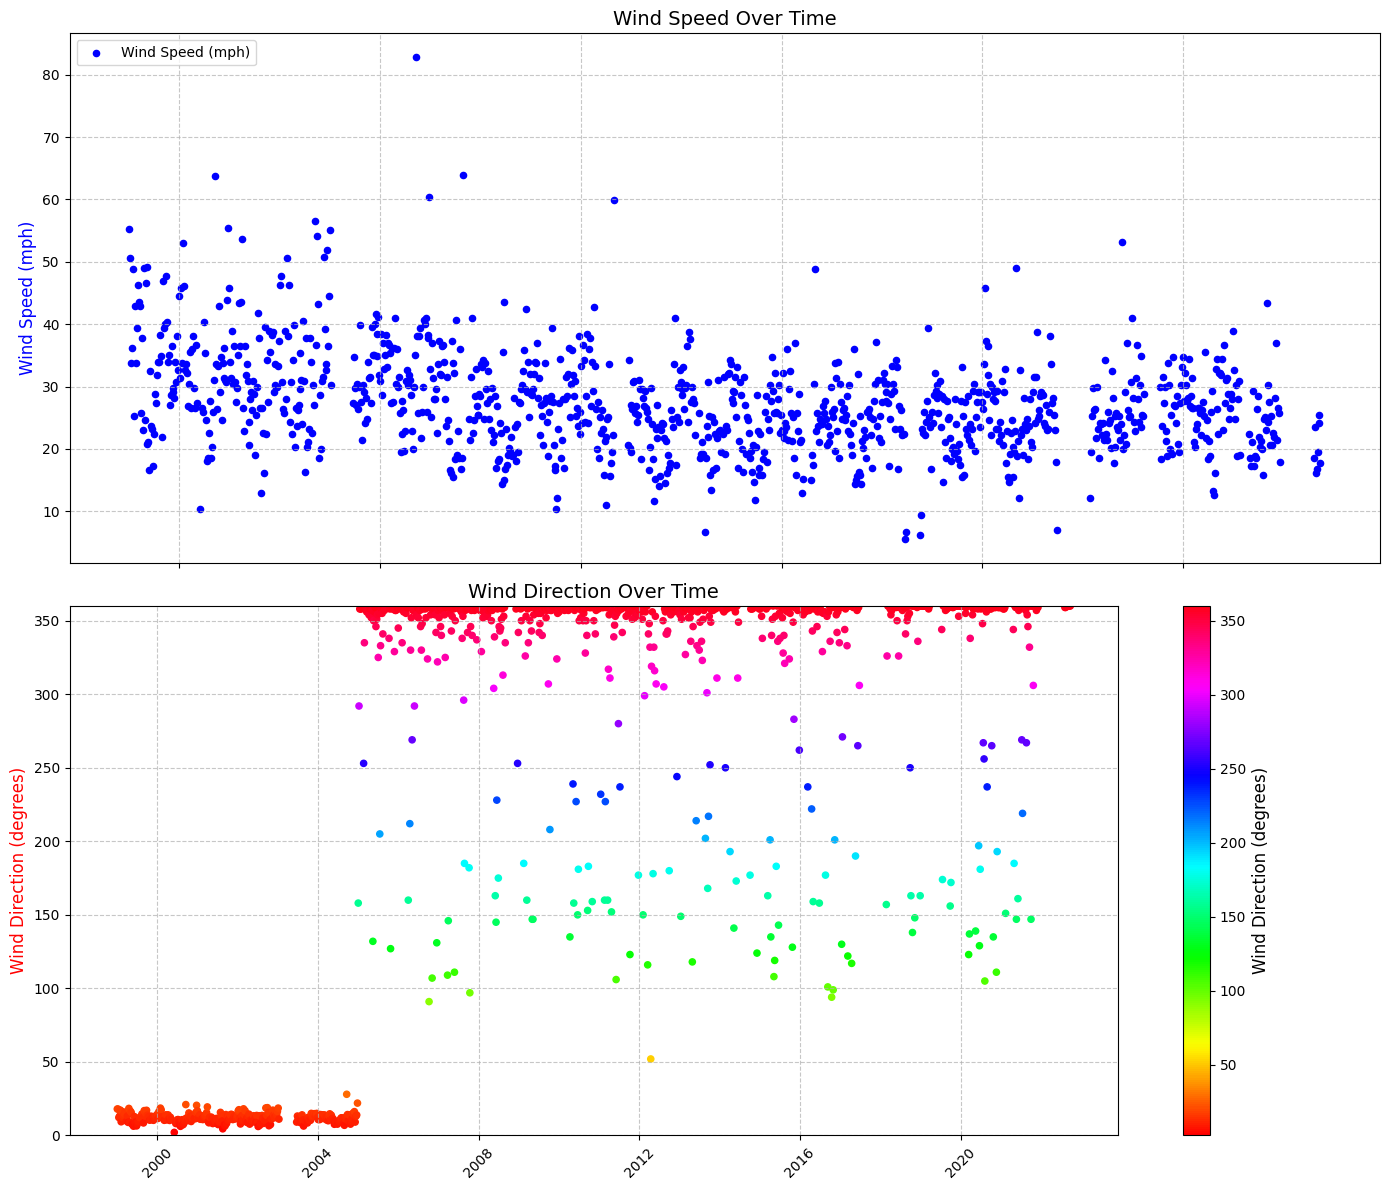

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ✅ Load the data
file_path = 'wind_data_gulf_of_mexico.csv'
data = pd.read_csv(file_path)

# ✅ Convert timestamp to datetime
data['Timestamp'] = pd.to_datetime(data['Timestamp'], errors='coerce')

# ✅ Remove unrealistic values (999, 9999) and drop NaN
data.replace([999, 999.0, 9999, 9999.0], np.nan, inplace=True)
data.dropna(subset=['WindSpeed', 'WindDirection', 'Timestamp'], inplace=True)

# ✅ Convert wind speed from m/s to mph (1 m/s = 2.23694 mph)
data['WindSpeed'] = data['WindSpeed'] * 2.23694

# ✅ Remove outliers (e.g., hurricane speeds above 150 mph)
data = data[data['WindSpeed'] <= 150]

# ✅ Resample to monthly data to reduce noise
data = data.set_index('Timestamp').resample('W').max().reset_index()

# ✅ Create subplots
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 12), sharex=True)

# ✅ Plot wind speed over time (in mph) as dots
ax1.scatter(data['Timestamp'], data['WindSpeed'], color='blue', label='Wind Speed (mph)', s=20)
ax1.set_ylabel('Wind Speed (mph)', color='blue', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_title('Wind Speed Over Time', fontsize=14)

# ✅ Plot wind direction over time (in degrees) with color mapping
scatter = ax2.scatter(
    data['Timestamp'],
    data['WindDirection'],
    c=data['WindDirection'],
    cmap='hsv',  # hsv is better for circular data
    marker='o',
    s=20
)

# ✅ Set y-axis limits to 0–360 degrees for wind direction
ax2.set_ylim(0, 360)
ax2.set_ylabel('Wind Direction (degrees)', color='red', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_title('Wind Direction Over Time', fontsize=14)

# ✅ Add color bar for wind direction
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Wind Direction (degrees)', fontsize=12)

# ✅ Fix x-axis labels
ax2.xaxis.set_tick_params(rotation=45)
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

# ✅ Improve spacing and layout
plt.tight_layout()

# ✅ Save and display the figure
plt.savefig('wind_speed_direction_cleaned.png', dpi=300)
plt.show()


In [138]:
import requests
import io
import pandas as pd

# ✅ Station and year settings
STATION_ID = '42003'
START_YEAR = 1990
END_YEAR = 2022

# ✅ Function to download and process data
def process_data(year):
    url = f"https://www.ndbc.noaa.gov/view_text_file.php?filename={STATION_ID}h{year}.txt.gz&dir=data/historical/stdmet/"

    try:
        print(f"📥 Downloading data for year {year}...")
        response = requests.get(url)
        if response.status_code != 200:
            print(f"❌ Failed to download data for year {year}: HTTP {response.status_code}")
            return None

        # ✅ Read data into pandas
        raw_data = io.StringIO(response.content.decode('utf-8'))
        df = pd.read_csv(raw_data, sep='\s+', comment='#', header=None, on_bad_lines='skip')

        # ✅ Match headers based on year
        if 1990 <= year <= 1999:
            headers = [
                'YY', 'MM', 'DD', 'hh', 'WD', 'WSPD', 'GST', 'WVHT', 'DPD', 'APD',
                'MWD', 'BAR', 'ATMP', 'WTMP', 'DEWP', 'VIS'
            ]

        elif 2000 <= year <= 2004:
            headers = [
                'YYYY', 'MM', 'DD', 'hh', 'WD', 'WSPD', 'GST', 'WVHT', 'DPD', 'APD',
                'MWD', 'BAR', 'ATMP', 'WTMP', 'DEWP', 'VIS', 'TIDE'
            ]
      
        elif 2005 <= year <= 2006:
            headers = [
                'YYYY', 'MM', 'DD', 'hh', 'mm', 'WD', 'WSPD', 'GST', 'WVHT', 'DPD',
                'APD', 'MWD', 'BAR', 'ATMP', 'WTMP', 'DEWP', 'VIS', 'TIDE'
            ]
        else:  # 2007+
            headers = [
                'YYYY', 'MM', 'DD', 'hh', 'mm', 'WDIR', 'WSPD', 'GST', 'WVHT', 'DPD',
                'APD', 'MWD', 'PRES', 'ATMP', 'WTMP', 'DEWP', 'VIS', 'TIDE'
            ]

        # ✅ Ensure number of columns matches the header length
        if len(df.columns) != len(headers):
            print(f"❌ Column mismatch for year {year}: Expected {len(headers)}, got {len(df.columns)}")
            return None

        # ✅ Assign headers
        df.columns = headers

        # ✅ Convert 2-digit year to 4-digit format if needed
        if 'YY' in df.columns:
            df['YY'] = pd.to_numeric(df['YY'], errors='coerce').fillna(0).astype(int)
            df['YYYY'] = df['YY'].apply(lambda x: x + 1900 if x > 50 else x + 2000)
            df.drop(columns=['YY'], inplace=True)

        # ✅ Rename to match pd.to_datetime requirements
        df.rename(columns={
            'YYYY': 'year',
            'MM': 'month',
            'DD': 'day',
            'hh': 'hour',
            'mm': 'minute',
            'WDIR': 'WD',   # Normalize wind direction column
            'PRES': 'BAR'   # Normalize pressure column
        }, inplace=True)

        # ✅ Fill missing minute column with 0 if not present
        if 'minute' not in df.columns:
            df['minute'] = 0

        # ✅ Create a single 'Timestamp' column
        df['Timestamp'] = pd.to_datetime(
            df[['year', 'month', 'day', 'hour', 'minute']],
            errors='coerce'
        )

        # ✅ Drop rows with invalid timestamps
        df.dropna(subset=['Timestamp'], inplace=True)

        # ✅ Keep only necessary columns (wind speed and wind direction)
        df = df[['Timestamp', 'WD', 'WSPD']]

        # ✅ Drop rows with missing values
        df.dropna(inplace=True)

        # ✅ Set timestamp as the index
        df.set_index('Timestamp', inplace=True)

        # ✅ Print final header
        print(f"✅ Processed data for year {year}: {list(df.columns)}")

        return df

    except Exception as e:
        print(f"❌ Failed to process data for year {year}: {e}")
        return None

# ✅ Loop through years and combine data
all_data = []

for year in range(START_YEAR, END_YEAR + 1):
    data = process_data(year)
    if data is not None:
        all_data.append(data)

# ✅ Combine all processed data
if all_data:
    final_data = pd.concat(all_data)
    final_data.sort_index(inplace=True)

    # ✅ Save to CSV
    final_data.to_csv('wind_data_cleaned.csv')
    print("\n✅ Final combined data saved to 'wind_data_cleaned.csv'")

    # ✅ Print final data preview
    print("\n✅ Final data preview:")
    print(final_data.head())

else:
    print("\n❌ No valid data to combine!")


📥 Downloading data for year 1990...
✅ Processed data for year 1990: ['WD', 'WSPD']
📥 Downloading data for year 1991...
✅ Processed data for year 1991: ['WD', 'WSPD']
📥 Downloading data for year 1992...
✅ Processed data for year 1992: ['WD', 'WSPD']
📥 Downloading data for year 1993...
✅ Processed data for year 1993: ['WD', 'WSPD']
📥 Downloading data for year 1994...
✅ Processed data for year 1994: ['WD', 'WSPD']
📥 Downloading data for year 1995...
✅ Processed data for year 1995: ['WD', 'WSPD']
📥 Downloading data for year 1996...
✅ Processed data for year 1996: ['WD', 'WSPD']
📥 Downloading data for year 1997...
✅ Processed data for year 1997: ['WD', 'WSPD']
📥 Downloading data for year 1998...
✅ Processed data for year 1998: ['WD', 'WSPD']
📥 Downloading data for year 1999...
✅ Processed data for year 1999: ['WD', 'WSPD']
📥 Downloading data for year 2000...
✅ Processed data for year 2000: ['WD', 'WSPD']
📥 Downloading data for year 2001...
✅ Processed data for year 2001: ['WD', 'WSPD']
📥 Do

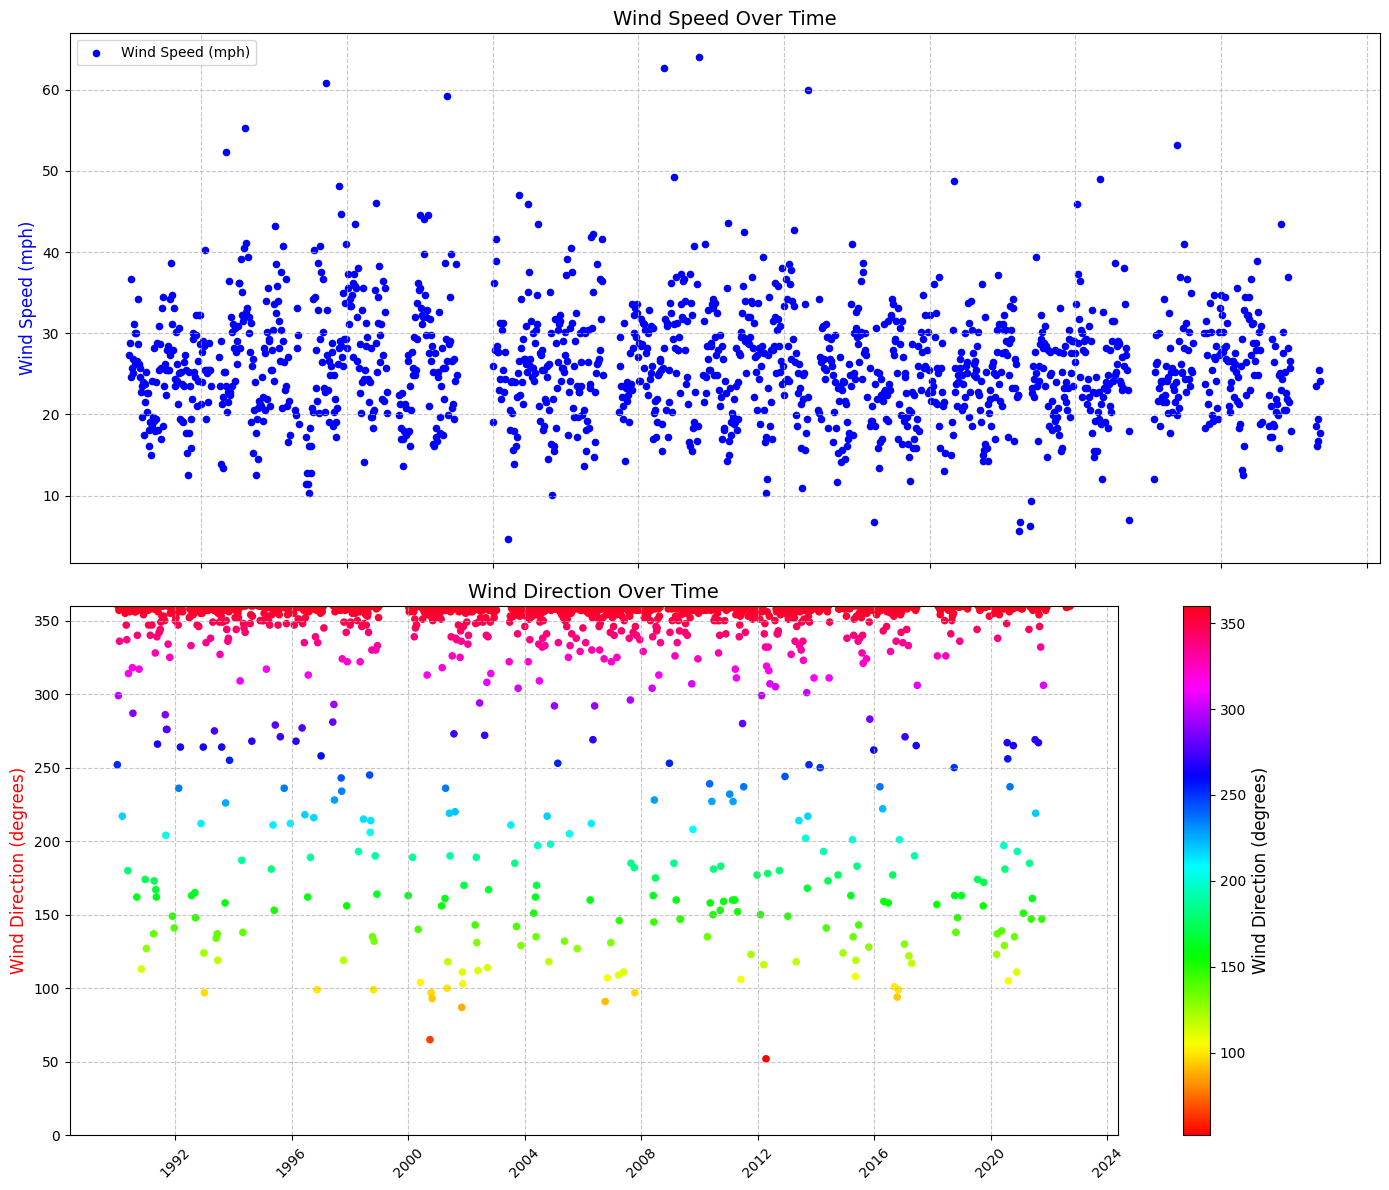

In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ✅ Load the cleaned data
file_path = 'wind_data_cleaned.csv'
data = pd.read_csv(file_path)

# ✅ Convert timestamp to datetime
data['Timestamp'] = pd.to_datetime(data['Timestamp'], errors='coerce')

# ✅ Remove unrealistic values (999, 999.0, 9999, 9999.0) and drop NaN
data.replace([999, 999.0, 9999, 9999.0], np.nan, inplace=True)
data.dropna(subset=['WSPD', 'WD', 'Timestamp'], inplace=True)

# ✅ Convert wind speed from m/s to mph (1 m/s = 2.23694 mph)
data['WSPD'] = data['WSPD'] * 2.23694

# ✅ Remove outliers (e.g., hurricane speeds above 150 mph)
data = data[data['WSPD'] <= 150]

# ✅ Resample to weekly data to reduce noise
data = data.set_index('Timestamp').resample('W').max().reset_index()

# ✅ Create subplots
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 12), sharex=True)

# ✅ Plot wind speed over time (in mph) as dots
ax1.scatter(data['Timestamp'], data['WSPD'], color='blue', label='Wind Speed (mph)', s=20)
ax1.set_ylabel('Wind Speed (mph)', color='blue', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_title('Wind Speed Over Time', fontsize=14)

# ✅ Plot wind direction over time (in degrees) with color mapping
scatter = ax2.scatter(
    data['Timestamp'],
    data['WD'],
    c=data['WD'],
    cmap='hsv',  # hsv is better for circular data
    marker='o',
    s=20
)

# ✅ Set y-axis limits to 0–360 degrees for wind direction
ax2.set_ylim(0, 360)
ax2.set_ylabel('Wind Direction (degrees)', color='red', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_title('Wind Direction Over Time', fontsize=14)

# ✅ Add color bar for wind direction
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Wind Direction (degrees)', fontsize=12)

# ✅ Fix x-axis labels
ax2.xaxis.set_tick_params(rotation=45)
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

# ✅ Improve spacing and layout
plt.tight_layout()

# ✅ Save and display the figure
plt.savefig('wind_speed_direction_cleaned.png', dpi=300)
plt.show()


Weekly Max Mean Wind Direction: 113.11 degrees
Weekly Max Resultant Wind Speed: 25.94 m/s

Weekly Max Wind Direction Bins:
 WD_bin
NW    695
SE     60
E      40
S      38
W      35
SW     28
NE      1
N       0
Name: count, dtype: int64


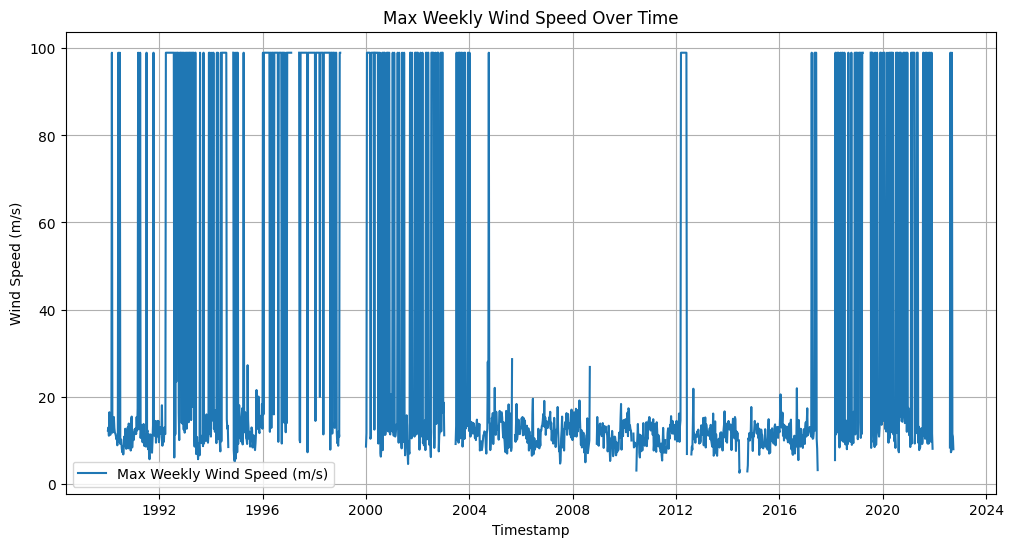

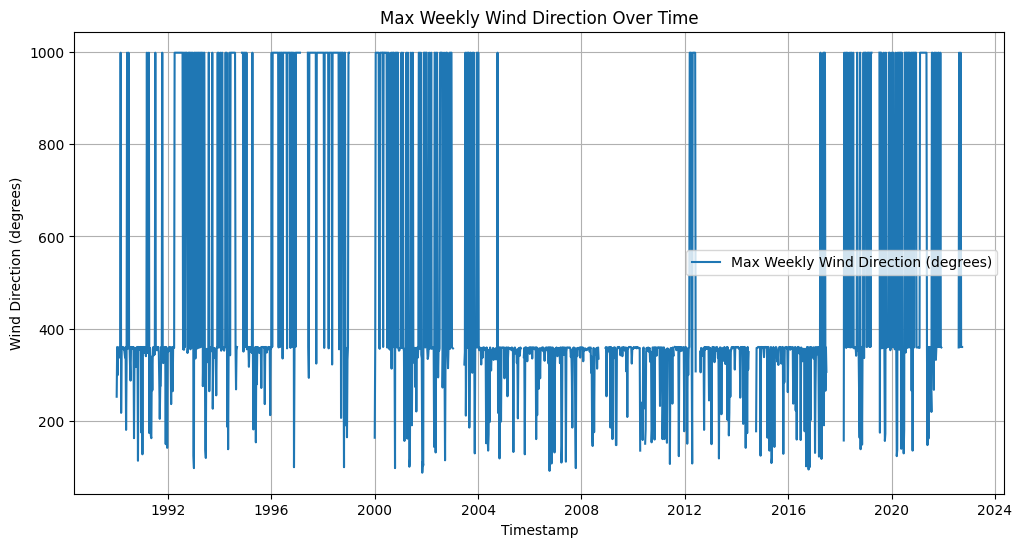

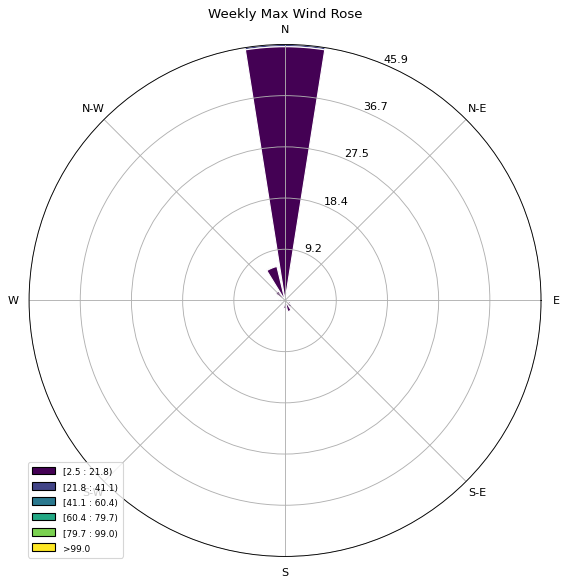

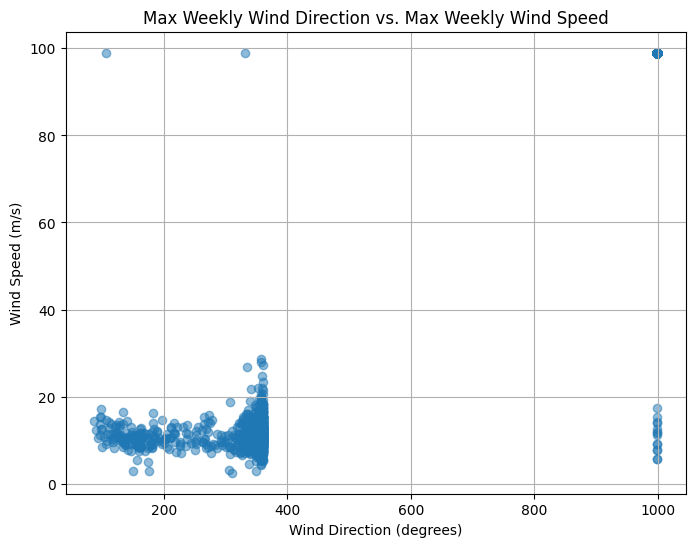

In [143]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from windrose import WindroseAxes
import matplotlib.cm as cm

# 1. Load and Prepare the Data
df = pd.read_csv('wind_data_cleaned.csv', parse_dates=['Timestamp'], index_col='Timestamp')
df['WD'] = pd.to_numeric(df['WD'], errors='coerce')
df['WSPD'] = pd.to_numeric(df['WSPD'], errors='coerce')
df.dropna(inplace=True)

# 2. Resample Weekly and Get Max Values
weekly_max = df.resample('W').max()

# 3. Process Wind Direction Data (using resampled data)
weekly_max['WD_rad'] = np.radians(weekly_max['WD'])
weekly_max['U'] = -weekly_max['WSPD'] * np.sin(weekly_max['WD_rad'])
weekly_max['V'] = -weekly_max['WSPD'] * np.cos(weekly_max['WD_rad'])

def calculate_mean_wind_direction(u, v):
    mean_u = np.mean(u)
    mean_v = np.mean(v)
    mean_direction_rad = np.arctan2(mean_u, mean_v)
    mean_direction_deg = (np.degrees(mean_direction_rad) + 360) % 360
    return mean_direction_deg

def calculate_resultant_wind_speed(u, v):
    mean_u = np.mean(u)
    mean_v = np.mean(v)
    resultant_speed = np.sqrt(mean_u**2 + mean_v**2)
    return resultant_speed

mean_wind_direction = calculate_mean_wind_direction(weekly_max['U'], weekly_max['V'])
resultant_wind_speed = calculate_resultant_wind_speed(weekly_max['U'], weekly_max['V'])

print(f"Weekly Max Mean Wind Direction: {mean_wind_direction:.2f} degrees")
print(f"Weekly Max Resultant Wind Speed: {resultant_wind_speed:.2f} m/s")

bins = [0, 45, 90, 135, 180, 225, 270, 315, 360]
labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
weekly_max['WD_bin'] = pd.cut(weekly_max['WD'], bins=bins, labels=labels, right=False)
print("\nWeekly Max Wind Direction Bins:\n", weekly_max['WD_bin'].value_counts())

# 4. Visualizations (using resampled data)
# a. Time Series Plots (Weekly Max)
plt.figure(figsize=(12, 6))
plt.plot(weekly_max['WSPD'], label='Max Weekly Wind Speed (m/s)')
plt.title('Max Weekly Wind Speed Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Wind Speed (m/s)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(weekly_max['WD'], label='Max Weekly Wind Direction (degrees)')
plt.title('Max Weekly Wind Direction Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Wind Direction (degrees)')
plt.legend()
plt.grid(True)
plt.show()

# b. Wind Rose Plot (Weekly Max) - Older Method (Corrected)
fig = plt.figure(figsize=(8, 8), dpi=80, facecolor='w', edgecolor='w')  # Create the figure
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection='windrose') # Create windrose axes and add it to the figure
ax.bar(weekly_max.WD, weekly_max.WSPD, normed=True, opening=0.8, edgecolor='white')
ax.set_legend()
plt.title("Weekly Max Wind Rose")
plt.show()


# c. Scatter Plot (Weekly Max Wind Direction vs. Wind Speed)
plt.figure(figsize=(8, 6))
plt.scatter(weekly_max['WD'], weekly_max['WSPD'], alpha=0.5)
plt.title('Max Weekly Wind Direction vs. Max Weekly Wind Speed')
plt.xlabel('Wind Direction (degrees)')
plt.ylabel('Wind Speed (m/s)')
plt.grid(True)
plt.show()